In [47]:
"""Train and evaluate linear regression models on the California Housing dataset."""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [48]:
"""加载数据集"""
housing = fetch_california_housing()
X = housing.data
y = housing.target

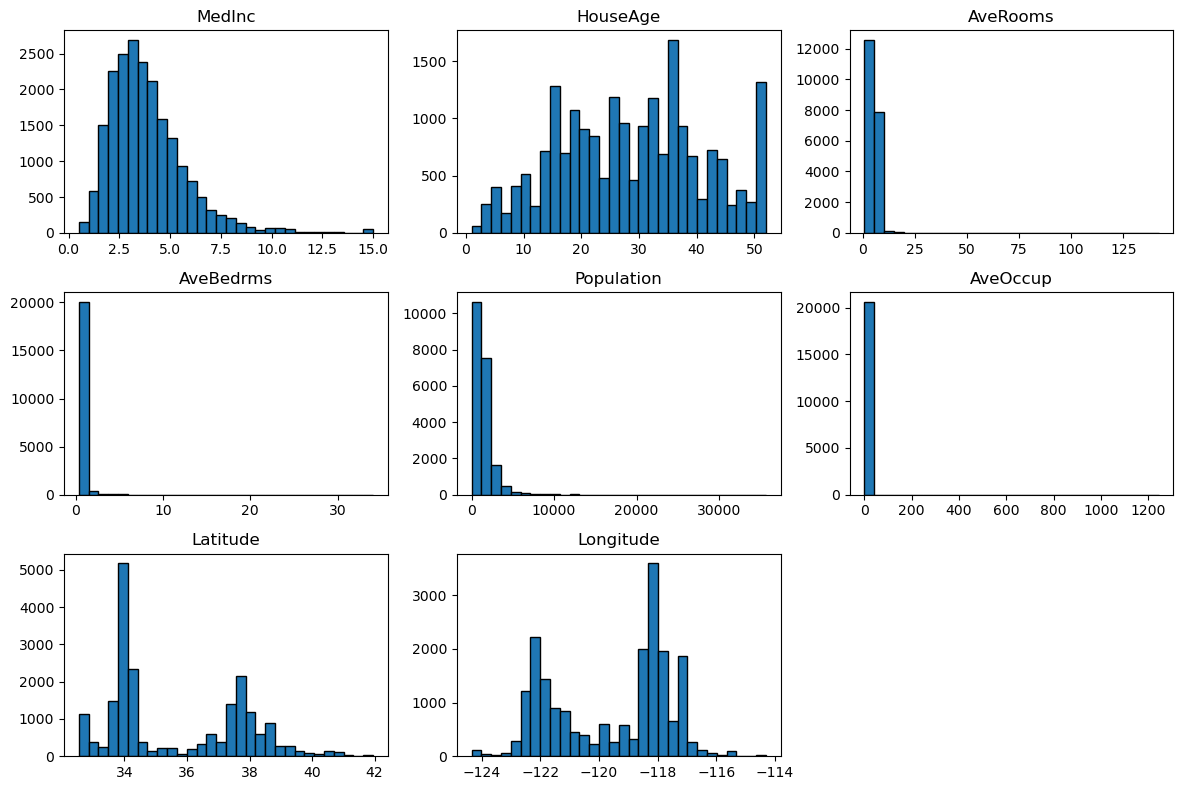

In [49]:
"""生成单变量分布图"""
plt.figure(figsize=(12, 8))
for i in range(X.shape[1]):
    plt.subplot(3, 3, i + 1)
    plt.hist(X[:, i], bins=30, edgecolor='k')
    plt.title(housing.feature_names[i])
plt.tight_layout()
plt.show()

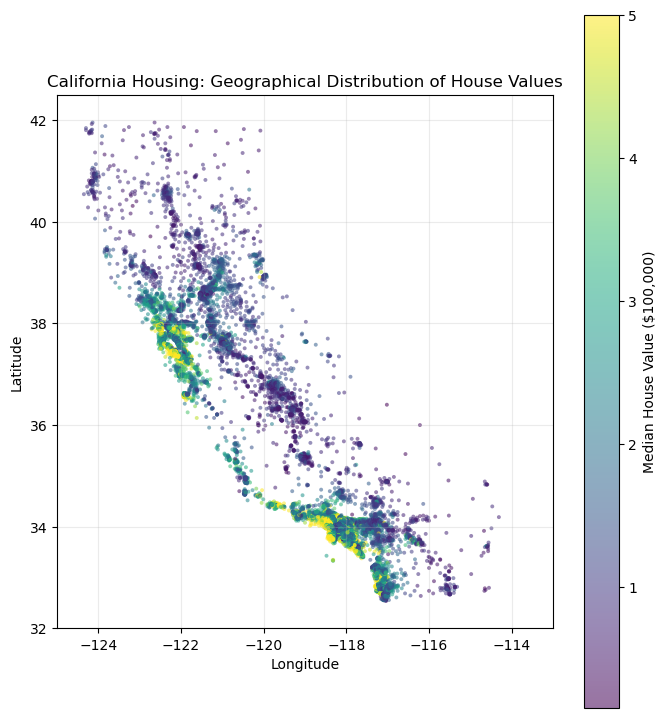

In [50]:
"""Visualize house values by California longitude and latitude."""
lon_idx = housing.feature_names.index("Longitude")
lat_idx = housing.feature_names.index("Latitude")

longitude = X[:, lon_idx]
latitude = X[:, lat_idx]

plt.figure(figsize=(8, 9))
scatter = plt.scatter(
    longitude,
    latitude,
    c=y,
    cmap="viridis",
    s=8,
    alpha=0.55,
    linewidths=0,
)
plt.colorbar(scatter, label="Median House Value ($100,000)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing: Geographical Distribution of House Values")

# California approximate lon/lat range. Aspect correction keeps the shape close to a map view.
plt.xlim(-125, -113)
plt.ylim(32, 42.5)
mean_lat = latitude.mean()
plt.gca().set_aspect(1 / np.cos(np.deg2rad(mean_lat)), adjustable="box")
plt.grid(alpha=0.25)
plt.show()

In [51]:
"""Split the dataset and prepare standardized features for gradient descent."""
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
"""Implement a linear regression model and train it with least squares."""
class MyLinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        # Least squares is more numerically stable than explicitly computing inv(X.T @ X).
        theta_best, *_ = np.linalg.lstsq(X_b, y, rcond=None)
        self.intercept_ = theta_best[0]
        self.coef_ = theta_best[1:]
        return self

    def predict(self, X):
        return X.dot(self.coef_) + self.intercept_

model = MyLinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predicted values (first 10):", y_pred[:10])

Predicted values (first 10): [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [53]:
"""评估模型性能"""
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.5558915986952457
R-squared: 0.5757877060324497


In [54]:
"""Optimize model parameters with gradient descent on standardized features."""
class MyLinearRegressionGD:
    def __init__(self, learning_rate=0.05, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]
        theta = np.zeros(n + 1)
        self.loss_history_ = []

        for iteration in range(self.n_iterations):
            pred = X_b @ theta
            error = pred - y
            gradients = (2 / m) * (X_b.T @ error)
            theta -= self.learning_rate * gradients
            self.loss_history_.append(np.mean(error ** 2))

            if not np.all(np.isfinite(theta)):
                raise FloatingPointError(
                    "Gradient descent diverged. Try a smaller learning_rate or standardize features."
                )

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self

    def predict(self, X):
        return X.dot(self.coef_) + self.intercept_

model_gd = MyLinearRegressionGD(learning_rate=0.05, n_iterations=2000)
model_gd.fit(X_train_scaled, y_train)
y_pred_gd = model_gd.predict(X_test_scaled)
print("Predicted values (Gradient Descent, first 10):", y_pred_gd[:10])

Predicted values (Gradient Descent, first 10): [0.71912832 1.76401198 2.70966614 2.83892064 2.60463949 2.01175786
 2.64549932 2.1687553  2.74074774 3.91562434]


In [55]:
"""Evaluate the gradient descent linear regression model."""
if "X_train_scaled" not in globals() or "X_test_scaled" not in globals():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

if "y_pred_gd" not in globals() or not np.all(np.isfinite(y_pred_gd)):
    print("Detected stale or invalid gradient descent predictions. Re-fitting the model...")
    model_gd = MyLinearRegressionGD(learning_rate=0.05, n_iterations=2000)
    model_gd.fit(X_train_scaled, y_train)
    y_pred_gd = model_gd.predict(X_test_scaled)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)
print("Gradient Descent Mean Squared Error:", mse_gd)
print("Gradient Descent R-squared:", r2_gd)

Gradient Descent Mean Squared Error: 0.5558926792462687
Gradient Descent R-squared: 0.5757868814417754


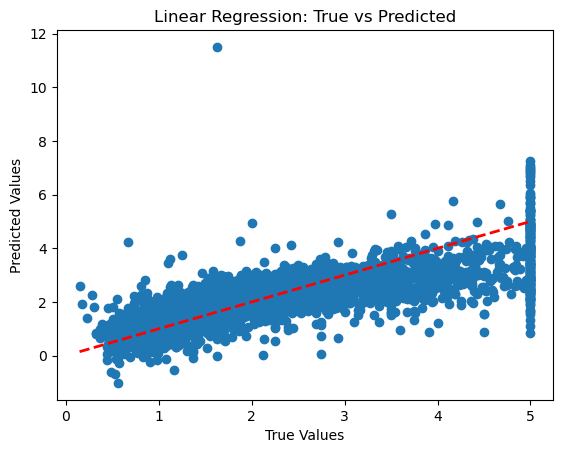

In [56]:
"""可视化模型的预测结果与真实值的关系"""
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: True vs Predicted')
plt.show()

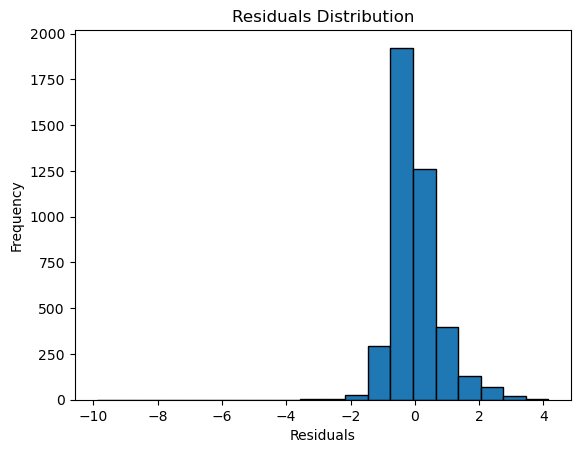

In [57]:
"""给出模型预测残差分布的图像，并分析残差分布是否满足线性回归模型的假设"""
residuals = y_test - y_pred
plt.hist(residuals, bins=20, edgecolor='k')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.show()

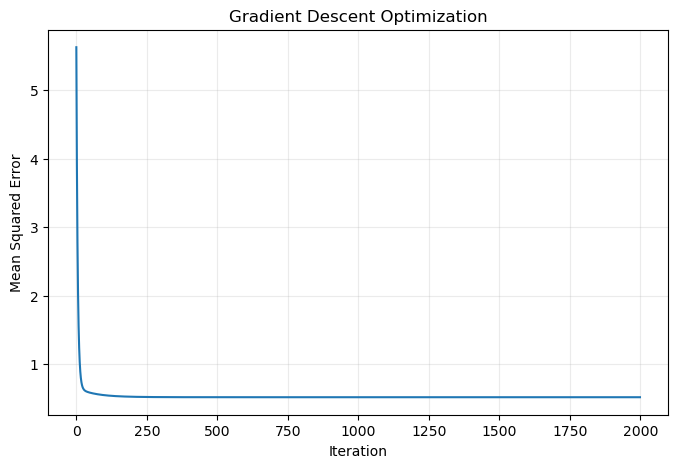

In [58]:
"""Visualize the loss curve during gradient descent optimization."""
if "model_gd" not in globals() or not getattr(model_gd, "loss_history_", None):
    print("No valid gradient descent history found. Re-fitting the model...")
    model_gd = MyLinearRegressionGD(learning_rate=0.05, n_iterations=2000)
    model_gd.fit(X_train_scaled, y_train)
    y_pred_gd = model_gd.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.plot(model_gd.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Optimization")
plt.grid(alpha=0.25)
plt.show()

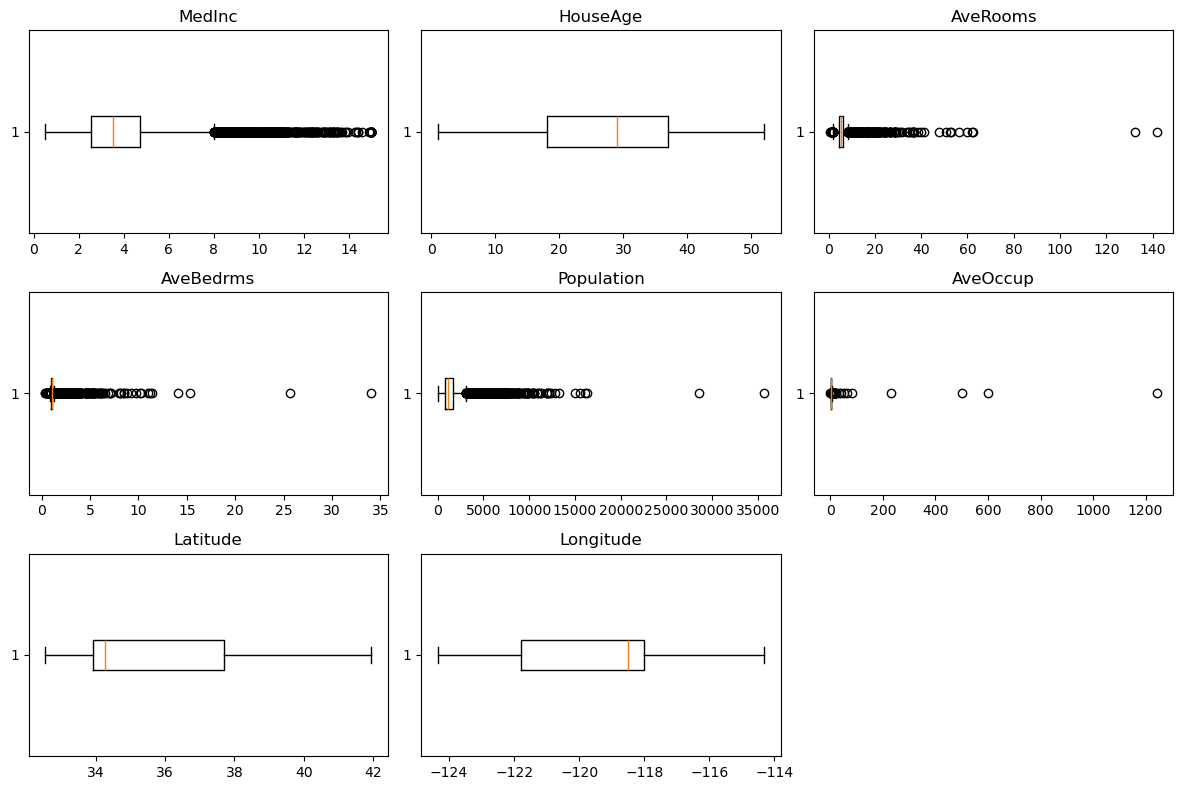

In [59]:
"""绘制箱型图比较不同特征的分布情况，并分析哪些特征可能对房价预测更有影响"""
plt.figure(figsize=(12, 8))
for i in range(X.shape[1]):
    plt.subplot(3, 3, i + 1)
    plt.boxplot(X[:, i], vert=False)
    plt.title(housing.feature_names[i])
plt.tight_layout()
plt.show()

In [60]:
"""分析异常样本点，剔除异常值后重新训练模型，并比较模型性能的变化"""
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(contamination=0.01, random_state=42)
outliers = isolation_forest.fit_predict(X_train_scaled) == -1
X_train_clean = X_train_scaled[~outliers]
y_train_clean = y_train[~outliers]
model_clean = MyLinearRegressionGD(learning_rate=0.05, n_iterations=2000)
model_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = model_clean.predict(X_test_scaled)
mse_clean = mean_squared_error(y_test, y_pred_clean)
print("Mean Squared Error after removing outliers:", mse_clean)

Mean Squared Error after removing outliers: 0.654627908204847
